# CS6493 - tutorial 5
## Fine-tune BERT for named entity recognition

In this tutorial, we will explore the utilization of BERT for for Named Entity Recognition (NER), a fundamental task in Natural Language Understanding (NLU). NER involves identifying and classifying named entities in text into predefined categories. Named entities are specific words or phrases that refer to real-world objects such as persons, organizations, locations, dates, numerical expressions, and more.


We are going to use **BertForTokenClassification** which is included in the [Transformers library](https://github.com/huggingface/transformers) by HuggingFace. This model has BERT as its base architecture, with a token classification head on top, allowing it to make predictions at the token level, rather than the sequence level. Named entity recognition is typically treated as a token classification problem, so that's what we are going to use it for.

This tutorial uses the idea of **transfer learning**, i.e. first pretraining a large neural network in an unsupervised way, and then fine-tuning that neural network on a task of interest. In this case, BERT is a neural network pretrained on 2 tasks: masked language modeling and next sentence prediction. Now, we are going to fine-tune this network on a NER dataset. Fine-tuning is supervised learning, so this means we will need a labeled dataset.

If you want to know more about BERT, we suggest the following resources:
* the original [paper](https://arxiv.org/abs/1810.04805)
* Jay Allamar's [blog post](http://jalammar.github.io/illustrated-bert/) as well as his [tutorial](http://jalammar.github.io/a-visual-guide-to-using-bert-for-the-first-time/)
* Chris Mccormick's [Youtube channel](https://www.youtube.com/channel/UCoRX98PLOsaN8PtekB9kWrw)
* Abbishek Kumar Mishra's [Youtube channel](https://www.youtube.com/user/abhisheksvnit)


### **Importing Python Libraries and preparing the environment**

This notebook assumes that you have the following libraries installed:
* pandas
* numpy
* sklearn
* pytorch
* transformers
* seqeval

As we are running this in Google Colab, please check the libraries of transformers and seqeval (GPU version) first:

In [ ]:
!pip install transformers

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score
import torch
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertConfig, BertForTokenClassification

We can set the default device to GPU using the following code (if it prints "cuda", it means the GPU has been recognized):

In [ ]:
from torch import cuda
device = 'cuda' if cuda.is_available() else 'cpu'
print(device)

cuda


### **Downloading and preprocessing the data**
Named entity recognition (NER) uses a specific annotation scheme, which is defined (at least for European languages) at the *word* level. An annotation scheme that is widely used is called **[IOB-tagging](https://en.wikipedia.org/wiki/Inside%E2%80%93outside%E2%80%93beginning_(tagging))**, which stands for Inside-Outside-Beginning. Each tag indicates whether the corresponding word is *inside*, *outside* or at the *beginning* of a specific named entity. The reason this is used is because named entities usually comprise more than 1 word.

Let's have a look at an example. If you have a sentence like "Barack Obama was born in Hawaï", then the corresponding tags would be   [B-PERS, I-PERS, O, O, O, B-GEO]. B-PERS means that the word "Barack" is the beginning of a person, I-PERS means that the word "Obama" is inside a person, "O" means that the word "was" is outside a named entity, and so on. So one typically has as many tags as there are words in a sentence.

So if you want to train a deep learning model for NER, it requires that you have your data in this IOB format. Here, we will use a NER dataset from [Kaggle](https://www.kaggle.com/namanj27/ner-dataset) that is already in IOB format. We have prepared the file in the Canvas page (Under Files/Tutorials). Let's update it into the Colab content:

In [ ]:
file = 'ner_datasetreference.csv'
data = pd.read_csv(file , encoding='unicode_escape')
data.head()

,Sentence #,Word,POS,Tag
0,Sentence: 1,Thousands,NNS,O
1,NaN,of,IN,O
2,NaN,demonstrators,NNS,O
3,NaN,have,VBP,O
4,NaN,marched,VBN,O


Let's check how many sentences and words (and corresponding tags) there are in this dataset:

In [ ]:
data.count()

,0
Sentence #,47959
Word,1048565
POS,1048575
Tag,1048575


As we can see, there are approximately 48,000 sentences in the dataset, comprising more than 1 million words and tags (quite huge!). This corresponds to approximately 20 words per sentence.

Let's have a look at the different NER tags, and their frequency:

In [ ]:
print("Number of tags: {}".format(len(data.Tag.unique())))
frequencies = data.Tag.value_counts()
frequencies

Number of tags: 17


,count
Tag,
O,887908
B-geo,37644
B-tim,20333
B-org,20143
I-per,17251
B-per,16990
I-org,16784
B-gpe,15870
I-geo,7414


There are 8 category tags, each with a "beginning" and "inside" variant, and the "outside" tag. It is not really clear what these tags mean - "geo" probably stands for geographical entity, "gpe" for geopolitical entity, and so on. They do not seem to correspond with what the publisher says on Kaggle. Some tags seem to be underrepresented. Let's print them by frequency (highest to lowest):

In [ ]:
tags = {}
for tag, count in zip(frequencies.index, frequencies):
    if tag != "O":
        if tag[2:5] not in tags.keys():
            tags[tag[2:5]] = count
        else:
            tags[tag[2:5]] += count
    continue

print(sorted(tags.items(), key=lambda x: x[1], reverse=True))

[('geo', 45058), ('org', 36927), ('per', 34241), ('tim', 26861), ('gpe', 16068), ('art', 699), ('eve', 561), ('nat', 252)]


We remove "art", "eve" and "nat" named entities here, as performance on them will probably be not comparable to the other named entities.

In [ ]:
entities_to_remove = ["B-art", "I-art", "B-eve", "I-eve", "B-nat", "I-nat"]
data = data[~data.Tag.isin(entities_to_remove)]
data.head()

,Sentence #,Word,POS,Tag
0,Sentence: 1,Thousands,NNS,O
1,NaN,of,IN,O
2,NaN,demonstrators,NNS,O
3,NaN,have,VBP,O
4,NaN,marched,VBN,O


Now, we have to ask ourself the question: what is a training example in the case of NER, which is provided in a single forward pass? A training example is typically a **sentence**, with corresponding IOB tags. Let's group the words and corresponding tags by sentence:

In [ ]:
# pandas has a very handy "forward fill" function to fill missing values based on the last upper non-nan value
data = data.fillna(method='ffill')
data.head()

/tmp/ipython-input-3112152059.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method='ffill')


,Sentence #,Word,POS,Tag
0,Sentence: 1,Thousands,NNS,O
1,Sentence: 1,of,IN,O
2,Sentence: 1,demonstrators,NNS,O
3,Sentence: 1,have,VBP,O
4,Sentence: 1,marched,VBN,O


In [ ]:
# let's create a new column called "sentence" which groups the words by sentence
data['sentence'] = data[['Sentence #','Word','Tag']].groupby(['Sentence #'])['Word'].transform(lambda x: ' '.join(x))
# let's also create a new column called "word_labels" which groups the tags by sentence
data['word_labels'] = data[['Sentence #','Word','Tag']].groupby(['Sentence #'])['Tag'].transform(lambda x: ','.join(x))
data.head()

,Sentence #,Word,POS,Tag,sentence,word_labels
0,Sentence: 1,Thousands,NNS,O,Thousands of demonstrators have marched throug...,"O,O,O,O,O,O,B-geo,O,O,O,O,O,B-geo,O,O,O,O,O,B-..."
1,Sentence: 1,of,IN,O,Thousands of demonstrators have marched throug...,"O,O,O,O,O,O,B-geo,O,O,O,O,O,B-geo,O,O,O,O,O,B-..."
2,Sentence: 1,demonstrators,NNS,O,Thousands of demonstrators have marched throug...,"O,O,O,O,O,O,B-geo,O,O,O,O,O,B-geo,O,O,O,O,O,B-..."
3,Sentence: 1,have,VBP,O,Thousands of demonstrators have marched throug...,"O,O,O,O,O,O,B-geo,O,O,O,O,O,B-geo,O,O,O,O,O,B-..."
4,Sentence: 1,marched,VBN,O,Thousands of demonstrators have marched throug...,"O,O,O,O,O,O,B-geo,O,O,O,O,O,B-geo,O,O,O,O,O,B-..."


Let's have a look at the different NER tags.

We create 2 dictionaries: one that maps individual tags to indices, and one that maps indices to their individual tags. This is necessary in order to create the labels (as computers work with numbers = indices, rather than words = tags) - see further in this notebook.

In [ ]:
labels_to_ids = {k: v for v, k in enumerate(data.Tag.unique())}
ids_to_labels = {v: k for v, k in enumerate(data.Tag.unique())}
labels_to_ids

{'O': 0,
 'B-geo': 1,
 'B-gpe': 2,
 'B-per': 3,
 'I-geo': 4,
 'B-org': 5,
 'I-org': 6,
 'B-tim': 7,
 'I-per': 8,
 'I-gpe': 9,
 'I-tim': 10}

As we can see, there are now only 11 different tags.

Let's only keep the "sentence" and "word_labels" columns, and drop duplicates:

In [ ]:
data = data[["sentence", "word_labels"]].drop_duplicates().reset_index(drop=True)
data.head()

,sentence,word_labels
0,Thousands of demonstrators have marched throug...,"O,O,O,O,O,O,B-geo,O,O,O,O,O,B-geo,O,O,O,O,O,B-..."
1,Families of soldiers killed in the conflict jo...,"O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,B-per,O,O,..."
2,They marched from the Houses of Parliament to ...,"O,O,O,O,O,O,O,O,O,O,O,B-geo,I-geo,O"
3,"Police put the number of marchers at 10,000 wh...","O,O,O,O,O,O,O,O,O,O,O,O,O,O,O"
4,The protest comes on the eve of the annual con...,"O,O,O,O,O,O,O,O,O,O,O,B-geo,O,O,B-org,I-org,O,..."


In [ ]:
len(data)

47571

Let's verify that a random sentence and its corresponding tags are correct:

In [ ]:
data.iloc[8].sentence

'Iran this week restarted parts of the conversion process at its Isfahan nuclear plant .'

In [ ]:
data.iloc[8].word_labels

'B-gpe,O,O,O,O,O,O,O,O,O,O,B-geo,O,O,O'

### **Preparing the dataset and dataloader**

Now that our data is preprocessed, we can turn it into PyTorch tensors such that we can provide it to the model. Let's start by defining some key variables that will be used later on in the training/evaluation process:

In [ ]:
MAX_LEN = 128
TRAIN_BATCH_SIZE = 8
VALID_BATCH_SIZE = 4
EPOCHS = 1
LEARNING_RATE = 2e-5
MAX_GRAD_NORM = 10
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

A tricky part of NER with BERT is that BERT relies on **wordpiece tokenization**, rather than word tokenization. This means that we should also define the labels at the wordpiece-level, rather than the word-level!

For example, if you have word like "Washington" which is labeled as "b-gpe", but it gets tokenized to "Wash", "##ing", "##ton", then we will have to propagate the word’s original label to all of its wordpieces: "b-gpe", "b-gpe", "b-gpe". The model should be able to produce the correct labels for each individual wordpiece. The function below implements this.

In [ ]:
def tokenize_and_preserve_labels(sentence, text_labels, tokenizer):
    """
    Word piece tokenization makes it difficult to match word labels
    back up with individual word pieces. This function tokenizes each
    word one at a time so that it is easier to preserve the correct
    label for each subword. It is, of course, a bit slower in processing
    time, but it will help our model achieve higher accuracy.
    """

    tokenized_sentence = []
    labels = []

    sentence = sentence.strip()

    for word, label in zip(sentence.split(), text_labels.split(",")):

        # Tokenize the word and count # of subwords the word is broken into
        tokenized_word = tokenizer.tokenize(word)
        n_subwords = len(tokenized_word)

        # Add the tokenized word to the final tokenized word list
        tokenized_sentence.extend(tokenized_word)

        # Add the same label to the new list of labels `n_subwords` times
        labels.extend([label] * n_subwords)

    return tokenized_sentence, labels

Note that this is a **design decision**. You could also decide to only label the first wordpiece of each word and let the model only learn this (this is what was done in the original BERT paper, see Github discussion [here](https://github.com/huggingface/transformers/issues/64#issuecomment-443703063)). Another design decision could be to give the first wordpiece of each word the original word label, and then use the label “I-X” for all subsequent subwords of that word.

All of them lead to good performance.

Next, we define a regular PyTorch [dataset class](https://pytorch.org/docs/stable/data.html) (which transforms examples of a dataframe to PyTorch tensors). Here, each sentence gets tokenized, the special tokens that BERT expects are added, the tokens are padded or truncated based on the max length of the model, the attention mask is created and the labels are created based on the dictionary which we defined above.

In [ ]:
class dataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len):
        self.len = len(dataframe)
        self.data = dataframe
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __getitem__(self, index):
        # step 1: tokenize (and adapt corresponding labels)
        sentence = self.data.sentence[index]
        word_labels = self.data.word_labels[index]
        tokenized_sentence, labels = tokenize_and_preserve_labels(sentence, word_labels, self.tokenizer)

        # step 2: add special tokens (and corresponding labels)
        tokenized_sentence = ["[CLS]"] + tokenized_sentence + ["[SEP]"] # add special tokens
        labels.insert(0, "O") # add outside label for [CLS] token
        labels.insert(-1, "O") # add outside label for [SEP] token

        # step 3: truncating/padding
        maxlen = self.max_len

        if (len(tokenized_sentence) > maxlen):
          # truncate
          tokenized_sentence = tokenized_sentence[:maxlen]
          labels = labels[:maxlen]
        else:
          # pad
          tokenized_sentence = tokenized_sentence + ['[PAD]'for _ in range(maxlen - len(tokenized_sentence))]
          labels = labels + ["O" for _ in range(maxlen - len(labels))]

        # step 4: obtain the attention mask
        attn_mask = [1 if tok != '[PAD]' else 0 for tok in tokenized_sentence]

        # step 5: convert tokens to input ids
        ids = self.tokenizer.convert_tokens_to_ids(tokenized_sentence)

        label_ids = [labels_to_ids[label] for label in labels]
        # the following line is deprecated
        #label_ids = [label if label != 0 else -100 for label in label_ids]

        return {
              'ids': torch.tensor(ids, dtype=torch.long),
              'mask': torch.tensor(attn_mask, dtype=torch.long),
              #'token_type_ids': torch.tensor(token_ids, dtype=torch.long),
              'targets': torch.tensor(label_ids, dtype=torch.long)
        }

    def __len__(self):
        return self.len

Now, based on the class we defined above, we can create 2 datasets, one for training and one for testing. Let's use a 80/20 split:

In [ ]:
train_size = 0.8
train_dataset = data.sample(frac=train_size,random_state=200)
test_dataset = data.drop(train_dataset.index).reset_index(drop=True)
train_dataset = train_dataset.reset_index(drop=True)

print("FULL Dataset: {}".format(data.shape))
print("TRAIN Dataset: {}".format(train_dataset.shape))
print("TEST Dataset: {}".format(test_dataset.shape))

training_set = dataset(train_dataset, tokenizer, MAX_LEN)
testing_set = dataset(test_dataset, tokenizer, MAX_LEN)

FULL Dataset: (47571, 2)
TRAIN Dataset: (38057, 2)
TEST Dataset: (9514, 2)


Let's have a look at the first training example:

In [ ]:
training_set[0]

{'ids': tensor([  101, 23564, 21030,  2099,  4967,  2001,  9388,  1011,  6109,  2005,
          2634,  1012,   102,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,  

Now, let's define the corresponding PyTorch dataloaders:

In [ ]:
train_params = {'batch_size': TRAIN_BATCH_SIZE,
                'shuffle': True,
                'num_workers': 0
                }

test_params = {'batch_size': VALID_BATCH_SIZE,
                'shuffle': False,
                'num_workers': 0
                }

training_loader = DataLoader(training_set, **train_params)
testing_loader = DataLoader(testing_set, **test_params)

### **Defining the model**

Here we define the model, BertForTokenClassification, and load it with the pretrained weights of "bert-base-uncased". The only thing we need to additionally specify is the number of labels (as this will determine the architecture of the classification head).

Note that only the base layers are initialized with the pretrained weights. The token classification head of top has just randomly initialized weights, which we will train, together with the pretrained weights, using our labelled dataset. This is also printed as a warning when you run the code cell below.

Then, we move the model to the GPU.

In [ ]:
model = BertForTokenClassification.from_pretrained('bert-base-uncased', num_labels=len(labels_to_ids))
model.to(device)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized be

BertForTokenClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, el





### **Training the model**

We first define the optimizer. Here, we are just going to use Adam with a default learning rate. One can also decide to use more advanced ones such as AdamW (Adam with weight decay fix), which is [included](https://huggingface.co/transformers/main_classes/optimizer_schedules.html) in the Transformers repository, and a learning rate scheduler, but we are not going to do that here.

In [ ]:
optimizer = torch.optim.Adam(params=model.parameters(), lr=LEARNING_RATE)

Now let's define a regular PyTorch training function.

In [ ]:
# Defining the training function on the 80% of the dataset for tuning the bert model
def train(epoch):
    tr_loss, tr_accuracy = 0, 0
    nb_tr_examples, nb_tr_steps = 0, 0
    tr_preds, tr_labels = [], []
    # put model in training mode
    model.train()

    for idx, batch in enumerate(tqdm(training_loader)):

        ids = batch['ids'].to(device, dtype = torch.long)
        mask = batch['mask'].to(device, dtype = torch.long)
        targets = batch['targets'].to(device, dtype = torch.long)

        model_output = model(input_ids=ids, attention_mask=mask, labels=targets, return_dict=True)
        loss, tr_logits = model_output.loss, model_output.logits
        tr_loss += loss.item()

        nb_tr_steps += 1
        nb_tr_examples += targets.size(0)

        if idx % 500==0:
            loss_step = tr_loss/nb_tr_steps
            print(f"Training loss at {idx} training steps in epoch {epoch}: {loss_step}")

        # compute training accuracy
        flattened_targets = targets.view(-1) # shape (batch_size * seq_len,)
        active_logits = tr_logits.view(-1, model.num_labels) # shape (batch_size * seq_len, num_labels)
        flattened_predictions = torch.argmax(active_logits, axis=1) # shape (batch_size * seq_len,)
        # now, use mask to determine where we should compare predictions with targets (includes [CLS] and [SEP] token predictions)
        active_accuracy = mask.view(-1) == 1 # active accuracy is also of shape (batch_size * seq_len,)
        targets = torch.masked_select(flattened_targets, active_accuracy)
        predictions = torch.masked_select(flattened_predictions, active_accuracy)

        tr_preds.extend(predictions)
        tr_labels.extend(targets)

        tmp_tr_accuracy = accuracy_score(targets.cpu().numpy(), predictions.cpu().numpy())
        tr_accuracy += tmp_tr_accuracy

        # gradient clipping
        torch.nn.utils.clip_grad_norm_(
            parameters=model.parameters(), max_norm=MAX_GRAD_NORM
        )

        # backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    epoch_loss = tr_loss / nb_tr_steps
    tr_accuracy = tr_accuracy / nb_tr_steps
    print(f"Training loss epoch: {epoch_loss}")
    print(f"Training accuracy epoch: {tr_accuracy}")



And let's train the model!

In [ ]:
for epoch in range(EPOCHS):
    print(f"Training epoch: {epoch + 1}")
    train(epoch)

Training epoch: 1


  0%|          | 0/4758 [00:00<?, ?it/s]

Training loss at 0 training steps in epoch 0: 2.245965003967285


 11%|█         | 501/4758 [01:40<13:37,  5.21it/s]

Training loss at 500 training steps in epoch 0: 0.10535581292818763


...

Training loss at 4000 training steps in epoch 0: 0.040564200841588724


 95%|█████████▍| 4501/4758 [14:43<00:49,  5.14it/s]

Training loss at 4500 training steps in epoch 0: 0.039146654704497526


100%|██████████| 4758/4758 [15:32<00:00,  5.10it/s]


Training loss epoch: 0.03841220942681669
Training accuracy epoch: 0.9501475467982493


### **Evaluating the model**

Now that we've trained our model, we can evaluate its performance on the held-out test set (which is 20% of the data). Note that here, no gradient updates are performed, the model just outputs its logits.

In [ ]:
def valid(model, testing_loader):
    # put model in evaluation mode
    model.eval()

    eval_loss, eval_accuracy = 0, 0
    nb_eval_examples, nb_eval_steps = 0, 0
    eval_preds, eval_labels = [], []

    with torch.no_grad():
        for idx, batch in enumerate(tqdm(testing_loader)):

            ids = batch['ids'].to(device, dtype = torch.long)
            mask = batch['mask'].to(device, dtype = torch.long)
            targets = batch['targets'].to(device, dtype = torch.long)

            model_output = model(input_ids=ids, attention_mask=mask, labels=targets, return_dict=True)
            loss, eval_logits = model_output.loss, model_output.logits

            eval_loss += loss.item()

            nb_eval_steps += 1
            nb_eval_examples += targets.size(0)

            if idx % 500 == 0:
                loss_step = eval_loss/nb_eval_steps
                print(f"Validation loss at {idx} evaluation steps: {loss_step}")

            # compute evaluation accuracy
            flattened_targets = targets.view(-1) # shape (batch_size * seq_len,)
            active_logits = eval_logits.view(-1, model.num_labels) # shape (batch_size * seq_len, num_labels)
            flattened_predictions = torch.argmax(active_logits, axis=1) # shape (batch_size * seq_len,)
            # now, use mask to determine where we should compare predictions with targets (includes [CLS] and [SEP] token predictions)
            active_accuracy = mask.view(-1) == 1 # active accuracy is also of shape (batch_size * seq_len,)
            targets = torch.masked_select(flattened_targets, active_accuracy)
            predictions = torch.masked_select(flattened_predictions, active_accuracy)

            eval_labels.extend(targets)
            eval_preds.extend(predictions)

            tmp_eval_accuracy = accuracy_score(targets.cpu().numpy(), predictions.cpu().numpy())
            eval_accuracy += tmp_eval_accuracy

    #print(eval_labels)
    #print(eval_preds)

    labels = [ids_to_labels[id.item()] for id in eval_labels]
    predictions = [ids_to_labels[id.item()] for id in eval_preds]

    #print(labels)
    #print(predictions)

    eval_loss = eval_loss / nb_eval_steps
    eval_accuracy = eval_accuracy / nb_eval_steps
    print(f"Validation Loss: {eval_loss}")
    print(f"Validation Accuracy: {eval_accuracy}")

    return labels, predictions

As we can see below, performance is quite good! Accuracy on the test test is > 93%.

In [ ]:
labels, predictions = valid(model, testing_loader)

  0%|          | 3/2379 [00:00<01:54, 20.82it/s]

Validation loss at 0 evaluation steps: 0.020033355802297592


 21%|██        | 504/2379 [00:16<01:01, 30.49it/s]

Validation loss at 500 evaluation steps: 0.02589156387160958


 42%|████▏     | 1005/2379 [00:33<00:45, 30.00it/s]

...

Validation loss at 1500 evaluation steps: 0.024916435626908717


 84%|████████▍ | 2004/2379 [01:06<00:12, 31.23it/s]

Validation loss at 2000 evaluation steps: 0.025282622006799493


100%|██████████| 2379/2379 [01:18<00:00, 30.26it/s]


Validation Loss: 0.025430630955032143
Validation Accuracy: 0.9622006862997527


However, the accuracy metric is misleading, as a lot of labels are "outside" (O), even after omitting predictions on the [PAD] tokens. What is important is looking at the precision, recall and f1-score of the individual tags. For this, we use the seqeval Python library:

In [ ]:
equ_num = sum([int(predictions[i] == labels[i] and predictions[i] != 'O' and labels[i] != 'O') for i in range(len(labels))])

predicted_positive = sum([int(predictions[i] != 'O') for i in range(len(predictions))])
true_posistive = sum([int(labels[i] != 'O') for i in range(len(labels))])

p = equ_num / predicted_positive if predicted_positive > 0 else 0.0
r = equ_num / true_posistive if true_posistive > 0 else 0.0
f1 = 2 * p * r / (p + r)

print({"P": p, "R": r, "F1": f1})

{'P': 0.8307685261518732, 'R': 0.8177535333498637, 'F1': 0.824209653417546}


#### **Inference**

The fun part is when we can quickly test the model on new, unseen sentences.
Here, we use the prediction of the **first word piece of every word**. Note that the function we used to train our model (`tokenze_and_preserve_labels`) propagated the label to all subsequent word pieces (so you could for example also perform a majority vote on the predicted labels of all word pieces of a word).

*In other words, the code below does not take into account when predictions of different word pieces that belong to the same word do not match.*

In [ ]:
sentence = "India has a capital called Mumbai. On wednesday, the president will give a presentation"

inputs = tokenizer(sentence, padding='max_length', truncation=True, max_length=MAX_LEN, return_tensors="pt")

# move to gpu
ids = inputs["input_ids"].to(device)
mask = inputs["attention_mask"].to(device)
# forward pass
outputs = model(ids, mask)
logits = outputs[0]

active_logits = logits.view(-1, model.num_labels) # shape (batch_size * seq_len, num_labels)
flattened_predictions = torch.argmax(active_logits, axis=1) # shape (batch_size*seq_len,) - predictions at the token level

tokens = tokenizer.convert_ids_to_tokens(ids.squeeze().tolist())
token_predictions = [ids_to_labels[i] for i in flattened_predictions.cpu().numpy()]
wp_preds = list(zip(tokens, token_predictions)) # list of tuples. Each tuple = (wordpiece, prediction)

word_level_predictions = []
for pair in wp_preds:
  if (pair[0].startswith(" ##")) or (pair[0] in ['[CLS]', '[SEP]', '[PAD]']):
    # skip prediction
    continue
  else:
    word_level_predictions.append(pair[1])

# we join tokens, if they are not special ones
str_rep = " ".join([t[0] for t in wp_preds if t[0] not in ['[CLS]', '[SEP]', '[PAD]']]).replace(" ##", "")
print(str_rep)
print(word_level_predictions)

india has a capital called mumbai . on wednesday , the president will give a presentation
['B-geo', 'O', 'O', 'O', 'O', 'B-geo', 'O', 'O', 'B-tim', 'O', 'O', 'O', 'O', 'O', 'O', 'O']


In [ ]:
[washington]
[wash,##ing,##ton]
['O','B-geo','B-geo'] -> "O"

majority vote
['O','B-geo','B-geo'] -> 'B-geo'

#### **Saving the model for future use**

Finally, let's save the vocabulary, model weights and the model's configuration file to a directory, so that they can be re-loaded using the `from_pretrained()` class method.



In [ ]:
import os

directory = "/content/model"

if not os.path.exists(directory):
    os.makedirs(directory)

# save vocabulary of the tokenizer
tokenizer.save_vocabulary(directory)
# save the model weights and its configuration file
model.save_pretrained(directory)
print('All files saved')

All files saved


Notice that this is a temperal saving, which means you cannot find the model the next time you open the Colab.

If you want to save the model permanetly, please save it into google drive or on the huggingface/other stage.

In [ ]:
# initial your google drive path
DRIVE_PATH = "/content/drive/MyDrive/"
MODEL_SAVE_PATH = DRIVE_PATH + "ner_model"

# save to your google drive
model.save_pretrained(MODEL_SAVE_PATH)
tokenizer.save_vocabulary(MODEL_SAVE_PATH)
print(f"Model saved to: {MODEL_SAVE_PATH}")
print(f"Tokenizer saved to: {MODEL_SAVE_PATH}")

Model saved to: /content/drive/MyDrive/ner_model
Tokenizer saved to: /content/drive/MyDrive/ner_model


## New Trend on NLP: Prompt what you want with Open-Sourced LLMs
- directly prompt your training with [Claude-Sonnet-4.5](https://www.anthropic.com/news/claude-sonnet-4-5):
```json
I want to train the NER task with huggingface LLM model, please provide me we with the [dataset] and corresponding code with a ipy format
```


In [ ]:
# Install required packages
!pip install transformers datasets seqeval accelerate torch

In [ ]:
# Named Entity Recognition Training with Hugging Face
# Dataset: CoNLL-2003
# Model: DistilBERT (lightweight and efficient)



# Import libraries
import numpy as np
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification
)
from seqeval.metrics import classification_report, f1_score, precision_score, recall_score
import torch

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load CoNLL-2003 dataset
print("Loading CoNLL-2003 dataset...")
dataset = load_dataset("conll2003")

# Explore the dataset
print("\nDataset structure:")
print(dataset)
print("\nExample from training set:")
print(dataset["train"][0])

# Label names
label_list = dataset["train"].features["ner_tags"].feature.names
print(f"\nNER Labels: {label_list}")

# Create label mappings
id2label = {i: label for i, label in enumerate(label_list)}
label2id = {label: i for i, label in enumerate(label_list)}

# Load tokenizer and model
model_checkpoint = "distilbert-base-uncased"
print(f"\nLoading tokenizer and model: {model_checkpoint}")
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

model = AutoModelForTokenClassification.from_pretrained(
    model_checkpoint,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id
)

# Tokenization function
def tokenize_and_align_labels(examples):
    """
    Tokenize the text and align the labels with tokenized words.
    Some words may be split into multiple tokens, so we need to handle this.
    """
    tokenized_inputs = tokenizer(
        examples["tokens"],
        truncation=True,
        is_split_into_words=True,
        max_length=512
    )

    labels = []
    for i, label in enumerate(examples["ner_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []

        for word_idx in word_ids:
            # Special tokens have a word id that is None
            if word_idx is None:
                label_ids.append(-100)
            # We set the label for the first token of each word
            elif word_idx != previous_word_idx:
                label_ids.append(label[word_idx])
            # For other tokens in a word, we set the label to -100
            else:
                label_ids.append(-100)
            previous_word_idx = word_idx

        labels.append(label_ids)

    tokenized_inputs["labels"] = labels
    return tokenized_inputs

# Tokenize datasets
print("\nTokenizing datasets...")
tokenized_datasets = dataset.map(
    tokenize_and_align_labels,
    batched=True,
    remove_columns=dataset["train"].column_names
)

# Data collator
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

# Metric computation function
def compute_metrics(eval_pred):
    """
    Compute precision, recall, and F1 score for NER evaluation.
    """
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=2)

    # Remove ignored index (special tokens)
    true_predictions = [
        [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [label_list[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    results = {
        "precision": precision_score(true_labels, true_predictions),
        "recall": recall_score(true_labels, true_predictions),
        "f1": f1_score(true_labels, true_predictions),
    }

    return results

# Training arguments
training_args = TrainingArguments(
    output_dir="./ner-model",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    push_to_hub=False,
)

# Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# Train the model
print("\nStarting training...")
trainer.train()

# Evaluate on test set
print("\nEvaluating on test set...")
test_results = trainer.evaluate(tokenized_datasets["test"])
print(f"Test Results: {test_results}")

# Save the model
print("\nSaving model...")
trainer.save_model("./ner-model-final")
tokenizer.save_pretrained("./ner-model-final")

# Inference example
print("\n" + "="*50)
print("INFERENCE EXAMPLE")
print("="*50)

def predict_ner(text):
    """
    Perform NER prediction on a given text.
    """
    # Tokenize input
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Get predictions
    model.to(device)
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)

    predictions = torch.argmax(outputs.logits, dim=2)

    # Convert predictions to labels
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    predicted_labels = [id2label[pred.item()] for pred in predictions[0]]

    # Combine tokens and labels
    results = []
    for token, label in zip(tokens, predicted_labels):
        if token not in ["[CLS]", "[SEP]", "[PAD]"]:
            results.append((token, label))

    return results

# Test with example sentences
example_sentences = [
    "Apple Inc. is planning to open a new store in New York next month.",
    "Elon Musk founded SpaceX in 2002 and Tesla Motors in 2003.",
    "The European Union headquarters is located in Brussels, Belgium."
]

for sentence in example_sentences:
    print(f"\nText: {sentence}")
    predictions = predict_ner(sentence)
    print("Predictions:")
    for token, label in predictions:
        if label != "O":  # Only show non-O labels
            print(f"  {token}: {label}")

print("\n" + "="*50)
print("Training completed successfully!")
print("="*50)

# Additional: Get detailed classification report on test set
print("\nDetailed Classification Report:")
test_predictions = trainer.predict(tokenized_datasets["test"])
predictions = np.argmax(test_predictions.predictions, axis=2)

true_predictions = [
    [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
    for prediction, label in zip(predictions, test_predictions.label_ids)
]
true_labels = [
    [label_list[l] for (p, l) in zip(prediction, label) if l != -100]
    for prediction, label in zip(predictions, test_predictions.label_ids)
]

print(classification_report(true_labels, true_predictions))

Using device: cuda
Loading CoNLL-2003 dataset...


/usr/local/lib/python3.12/dist-packages/datasets/load.py:1461: FutureWarning: The repository for conll2003 contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/conll2003
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this dataset from the next major release of `datasets`.
  warnings.warn(



Dataset structure:
DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3453
    })
})

Example from training set:
{'id': '0', 'tokens': ['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.'], 'pos_tags': [22, 42, 16, 21, 35, 37, 16, 21, 7], 'chunk_tags': [11, 21, 11, 12, 21, 22, 11, 12, 0], 'ner_tags': [3, 0, 7, 0, 0, 0, 7, 0, 0]}

NER Labels: ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']

Loading tokenizer and model: distilbert-base-uncased


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForTokenClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



Evaluating on test set...


Test Results: {'eval_loss': 0.11608287692070007, 'eval_precision': 0.8879400487974904, 'eval_recall': 0.9020892351274787, 'eval_f1': 0.8949587212366064, 'eval_runtime': 4.5911, 'eval_samples_per_second': 752.11, 'eval_steps_per_second': 47.048, 'epoch': 3.0}

Saving model...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


INFERENCE EXAMPLE

Text: Apple Inc. is planning to open a new store in New York next month.
Predictions:
  apple: B-ORG
  inc: I-ORG
  .: I-ORG
  new: B-LOC
  york: I-LOC

Text: Elon Musk founded SpaceX in 2002 and Tesla Motors in 2003.
Predictions:
  el: B-PER
  ##on: B-PER
  mu: I-PER
  ##sk: I-PER
  space: B-ORG
  ##x: I-ORG
  tesla: B-ORG
  motors: I-ORG

Text: The European Union headquarters is located in Brussels, Belgium.
Predictions:
  european: B-ORG
  union: I-ORG
  brussels: B-LOC
  belgium: B-LOC

Training completed successfully!

Detailed Classification Report:
              precision    recall  f1-score   support

         LOC       0.91      0.92      0.91      1668
        MISC       0.75      0.80      0.78       702
         ORG       0.85      0.87      0.86      1661
         PER       0.97      0.96      0.97      1617

   micro avg       0.89      0.90      0.89      5648
   macro avg       0.87      0.89      0.88      5648
weighted avg       0.89      0.90     

- evaluate our model on the test set (wrote by Claude-Sonnet-4.5)

COMPREHENSIVE NER MODEL EVALUATION ON TEST SET

1. OVERALL METRICS



Test Set Metrics:
  eval_loss: 0.1161
  eval_precision: 0.8879
  eval_recall: 0.9021
  eval_f1: 0.8950
  eval_runtime: 4.7354
  eval_samples_per_second: 729.1870
  eval_steps_per_second: 45.6140
  epoch: 3.0000

2. DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

         LOC     0.9052    0.9221    0.9136      1668
        MISC     0.7523    0.8006    0.7757       702
         ORG     0.8492    0.8712    0.8600      1661
         PER     0.9748    0.9573    0.9660      1617

   micro avg     0.8879    0.9021    0.8950      5648
   macro avg     0.8704    0.8878    0.8788      5648
weighted avg     0.8897    0.9021    0.8957      5648


3. PER-ENTITY TYPE PERFORMANCE

PER (Person/Organization/Location/Miscellaneous):
  Precision: 0.9748
  Recall: 0.9573
  F1-Score: 0.9660

ORG (Person/Organization/Location/Miscellaneous):
  Precision: 0.8492
  Recall: 0.8712
  F1-Score: 0.8600

LOC (Person/Organization/Location/Miscellaneous):
  Precision: 0.9052
 

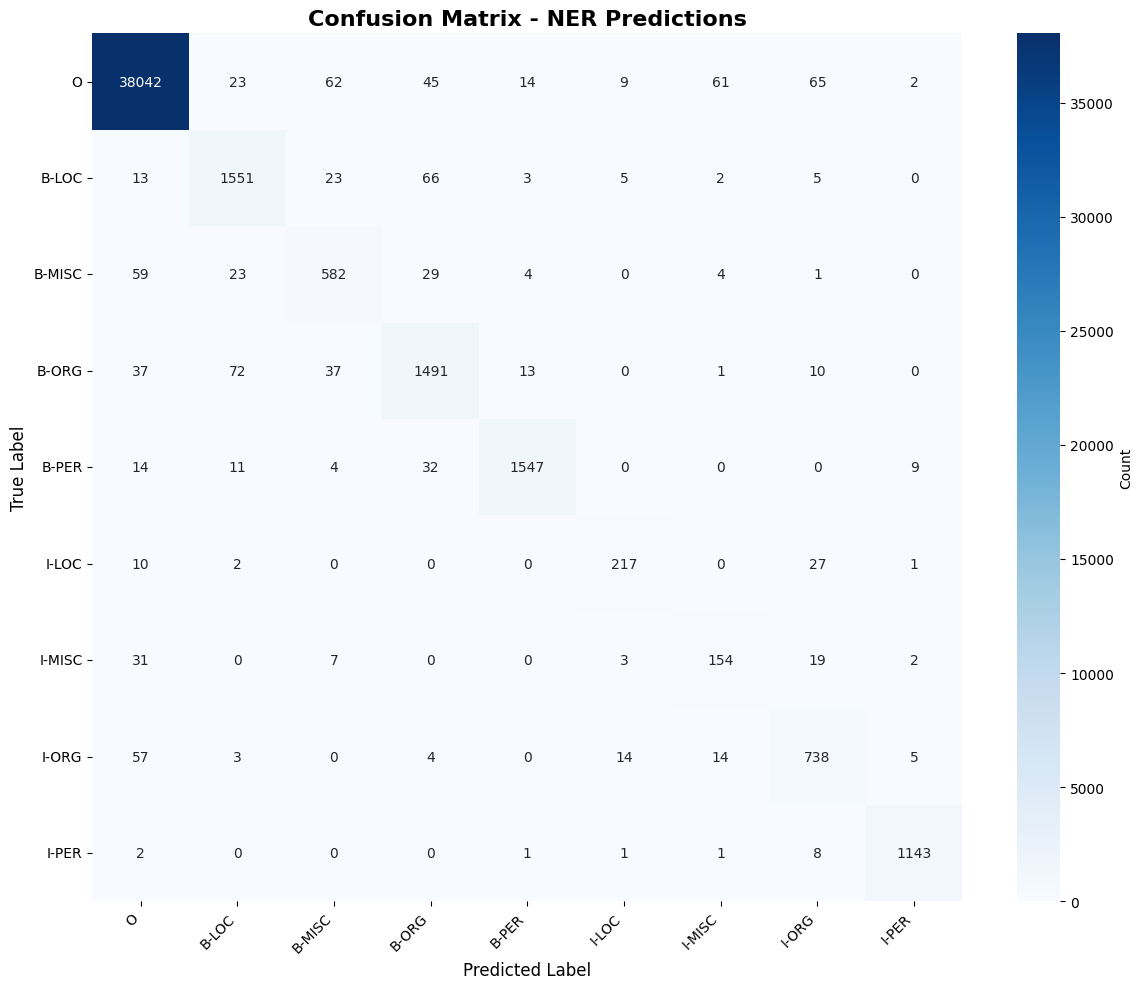


Confusion matrix saved as 'confusion_matrix.png'

5. ENTITY TYPE DISTRIBUTION IN TEST SET

Entity Distribution:
  O: 38323 (82.53%)
  B-LOC: 1668 (3.59%)
  B-ORG: 1661 (3.58%)
  B-PER: 1617 (3.48%)
  I-PER: 1156 (2.49%)
  I-ORG: 835 (1.80%)
  B-MISC: 702 (1.51%)
  I-LOC: 257 (0.55%)
  I-MISC: 216 (0.47%)


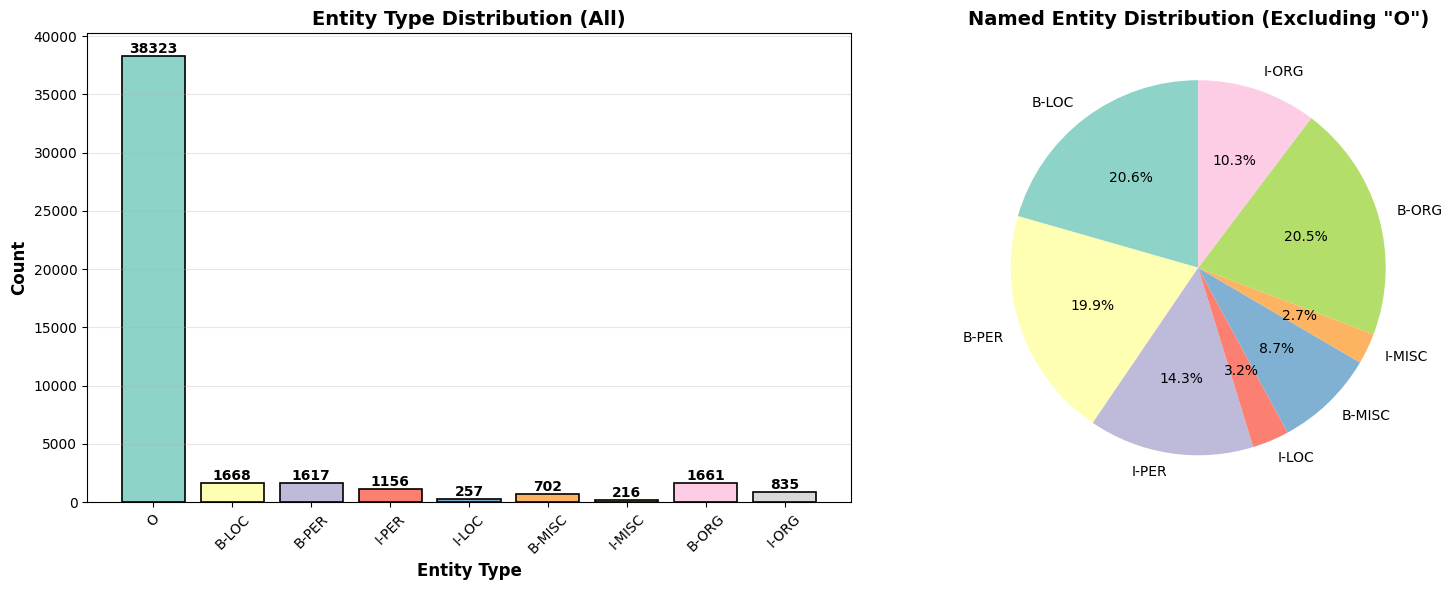


Entity distribution plot saved as 'entity_distribution.png'

6. ENTITY TYPE PERFORMANCE COMPARISON


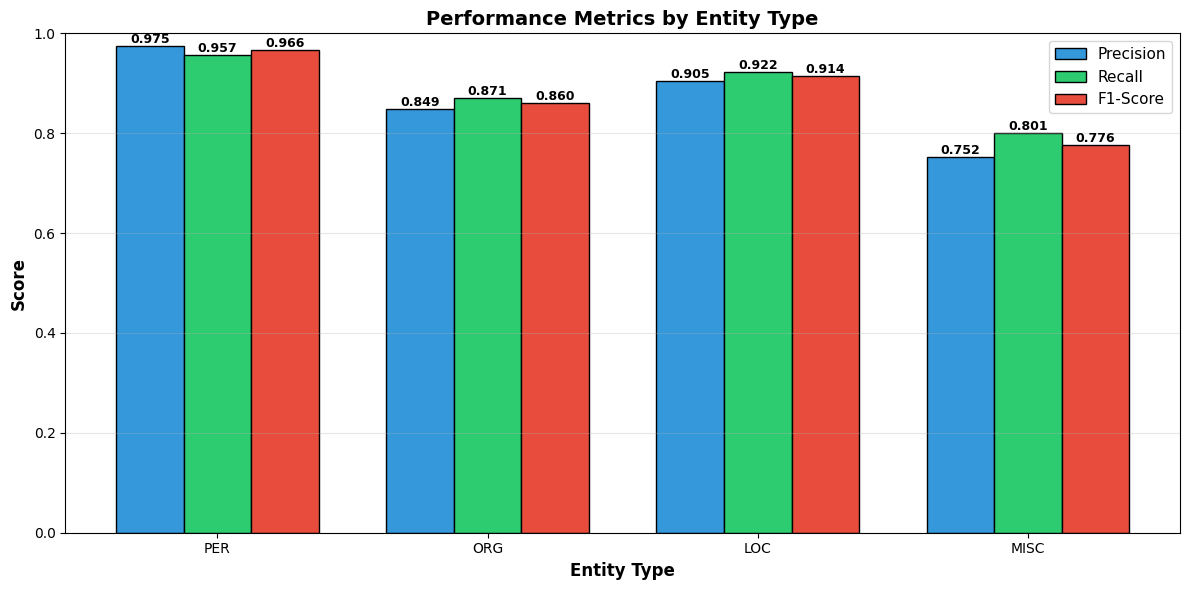


Performance comparison chart saved as 'performance_comparison.png'

7. ERROR ANALYSIS - COMMON MISTAKES

Top 10 Most Common Misclassifications:
  Predicted 'B-LOC' instead of 'B-ORG': 72 times
  Predicted 'B-ORG' instead of 'B-LOC': 66 times
  Predicted 'B-MISC' instead of 'B-ORG': 37 times
  Predicted 'B-ORG' instead of 'B-PER': 32 times
  Predicted 'B-ORG' instead of 'B-MISC': 29 times
  Predicted 'I-ORG' instead of 'I-LOC': 27 times
  Predicted 'B-LOC' instead of 'B-MISC': 23 times
  Predicted 'B-MISC' instead of 'B-LOC': 23 times
  Predicted 'I-ORG' instead of 'I-MISC': 19 times
  Predicted 'I-MISC' instead of 'I-ORG': 14 times

8. SAMPLE PREDICTIONS FROM TEST SET

--- Example 2619 ---
Tokens: ( 52.76 / 53.18 )

Token-level comparison:
Token True Label Predicted Label Match
    (          O               O     ✓
52.76          O               O     ✓
    /          O               O     ✓
53.18          O               O     ✓
    )          O               O     ✓

--- Example 45

In [ ]:
# Comprehensive Model Evaluation on Test Set

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from seqeval.metrics import (
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score
)
from sklearn.metrics import confusion_matrix
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("COMPREHENSIVE NER MODEL EVALUATION ON TEST SET")
print("="*70)

# 1. Basic Evaluation Metrics
print("\n" + "="*70)
print("1. OVERALL METRICS")
print("="*70)

# Get predictions on test set
test_results = trainer.evaluate(tokenized_datasets["test"])
print("\nTest Set Metrics:")
for key, value in test_results.items():
    print(f"  {key}: {value:.4f}")

# 2. Detailed Classification Report
print("\n" + "="*70)
print("2. DETAILED CLASSIFICATION REPORT")
print("="*70)

# Get predictions
test_predictions = trainer.predict(tokenized_datasets["test"])
predictions = np.argmax(test_predictions.predictions, axis=2)

# Convert to label names
true_predictions = [
    [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
    for prediction, label in zip(predictions, test_predictions.label_ids)
]
true_labels = [
    [label_list[l] for (p, l) in zip(prediction, label) if l != -100]
    for prediction, label in zip(predictions, test_predictions.label_ids)
]

# Print detailed report
print(classification_report(true_labels, true_predictions, digits=4))

# 3. Per-Entity Type Analysis
print("\n" + "="*70)
print("3. PER-ENTITY TYPE PERFORMANCE")
print("="*70)

# Calculate metrics for each entity type
entity_types = ['PER', 'ORG', 'LOC', 'MISC']
entity_metrics = []

for entity in entity_types:
    # Filter predictions for this entity type
    entity_true = []
    entity_pred = []

    for true_seq, pred_seq in zip(true_labels, true_predictions):
        entity_true.append([label if entity in label else 'O' for label in true_seq])
        entity_pred.append([label if entity in label else 'O' for label in pred_seq])

    precision = precision_score(entity_true, entity_pred)
    recall = recall_score(entity_true, entity_pred)
    f1 = f1_score(entity_true, entity_pred)

    entity_metrics.append({
        'Entity': entity,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

    print(f"\n{entity} (Person/Organization/Location/Miscellaneous):")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")

# 4. Confusion Matrix
print("\n" + "="*70)
print("4. CONFUSION MATRIX ANALYSIS")
print("="*70)

# Flatten predictions and labels
flat_true_labels = [label for seq in true_labels for label in seq]
flat_predictions = [label for seq in true_predictions for label in seq]

# Get unique labels (excluding 'O' for better visualization)
unique_labels = sorted(list(set(flat_true_labels + flat_predictions)))
if 'O' in unique_labels:
    unique_labels.remove('O')
    unique_labels = ['O'] + unique_labels

# Create confusion matrix
cm = confusion_matrix(flat_true_labels, flat_predictions, labels=unique_labels)

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=unique_labels,
            yticklabels=unique_labels,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - NER Predictions', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nConfusion matrix saved as 'confusion_matrix.png'")

# 5. Entity Type Distribution
print("\n" + "="*70)
print("5. ENTITY TYPE DISTRIBUTION IN TEST SET")
print("="*70)

# Count entity types
entity_counts = Counter(flat_true_labels)
print("\nEntity Distribution:")
for entity, count in sorted(entity_counts.items(), key=lambda x: x[1], reverse=True):
    percentage = (count / len(flat_true_labels)) * 100
    print(f"  {entity}: {count} ({percentage:.2f}%)")

# Visualize distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot of all entities
entities = list(entity_counts.keys())
counts = list(entity_counts.values())
colors = plt.cm.Set3(range(len(entities)))

ax1.bar(entities, counts, color=colors, edgecolor='black', linewidth=1.2)
ax1.set_xlabel('Entity Type', fontsize=12, fontweight='bold')
ax1.set_ylabel('Count', fontsize=12, fontweight='bold')
ax1.set_title('Entity Type Distribution (All)', fontsize=14, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (entity, count) in enumerate(zip(entities, counts)):
    ax1.text(i, count, str(count), ha='center', va='bottom', fontweight='bold')

# Pie chart (excluding 'O')
entity_counts_no_o = {k: v for k, v in entity_counts.items() if k != 'O'}
ax2.pie(entity_counts_no_o.values(),
        labels=entity_counts_no_o.keys(),
        autopct='%1.1f%%',
        startangle=90,
        colors=plt.cm.Set3(range(len(entity_counts_no_o))))
ax2.set_title('Named Entity Distribution (Excluding "O")', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('entity_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nEntity distribution plot saved as 'entity_distribution.png'")

# 6. Performance Comparison Chart
print("\n" + "="*70)
print("6. ENTITY TYPE PERFORMANCE COMPARISON")
print("="*70)

# Create DataFrame for visualization
df_metrics = pd.DataFrame(entity_metrics)

# Plot grouped bar chart
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(df_metrics))
width = 0.25

bars1 = ax.bar(x - width, df_metrics['Precision'], width, label='Precision',
               color='#3498db', edgecolor='black')
bars2 = ax.bar(x, df_metrics['Recall'], width, label='Recall',
               color='#2ecc71', edgecolor='black')
bars3 = ax.bar(x + width, df_metrics['F1-Score'], width, label='F1-Score',
               color='#e74c3c', edgecolor='black')

ax.set_xlabel('Entity Type', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Performance Metrics by Entity Type', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df_metrics['Entity'])
ax.legend(fontsize=11)
ax.set_ylim([0, 1.0])
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
def add_value_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

add_value_labels(bars1)
add_value_labels(bars2)
add_value_labels(bars3)

plt.tight_layout()
plt.savefig('performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nPerformance comparison chart saved as 'performance_comparison.png'")

# 7. Error Analysis
print("\n" + "="*70)
print("7. ERROR ANALYSIS - COMMON MISTAKES")
print("="*70)

# Find misclassifications
errors = []
for true_seq, pred_seq in zip(true_labels, true_predictions):
    for true_label, pred_label in zip(true_seq, pred_seq):
        if true_label != pred_label and true_label != 'O' and pred_label != 'O':
            errors.append((true_label, pred_label))

if errors:
    error_counts = Counter(errors)
    print("\nTop 10 Most Common Misclassifications:")
    for (true_label, pred_label), count in error_counts.most_common(10):
        print(f"  Predicted '{pred_label}' instead of '{true_label}': {count} times")
else:
    print("\nNo misclassifications between non-O labels found.")

# 8. Sample Predictions Analysis
print("\n" + "="*70)
print("8. SAMPLE PREDICTIONS FROM TEST SET")
print("="*70)

# Get original test examples
test_dataset = dataset["test"]

# Show 5 random examples with predictions
import random
sample_indices = random.sample(range(len(test_dataset)), min(5, len(test_dataset)))

for idx in sample_indices:
    example = test_dataset[idx]
    tokens = example['tokens']
    true_tags = [label_list[tag] for tag in example['ner_tags']]

    # Get predictions for this example
    pred_tags = true_predictions[idx]

    print(f"\n--- Example {idx} ---")
    print(f"Tokens: {' '.join(tokens)}")
    print(f"\nToken-level comparison:")

    # Create comparison table
    comparison_data = []
    for token, true_tag, pred_tag in zip(tokens, true_tags, pred_tags):
        match = "✓" if true_tag == pred_tag else "✗"
        comparison_data.append([token, true_tag, pred_tag, match])

    df_comparison = pd.DataFrame(comparison_data,
                                  columns=['Token', 'True Label', 'Predicted Label', 'Match'])
    print(df_comparison.to_string(index=False))

# 9. Summary Statistics
print("\n" + "="*70)
print("9. SUMMARY STATISTICS")
print("="*70)

total_tokens = len(flat_true_labels)
total_entities = sum(1 for label in flat_true_labels if label != 'O')
correct_predictions = sum(1 for true, pred in zip(flat_true_labels, flat_predictions) if true == pred)
accuracy = correct_predictions / total_tokens

print(f"\nTotal tokens in test set: {total_tokens}")
print(f"Total named entities: {total_entities} ({(total_entities/total_tokens)*100:.2f}%)")
print(f"Correct predictions: {correct_predictions}")
print(f"Token-level accuracy: {accuracy:.4f}")
print(f"\nOverall F1-Score: {f1_score(true_labels, true_predictions):.4f}")
print(f"Overall Precision: {precision_score(true_labels, true_predictions):.4f}")
print(f"Overall Recall: {recall_score(true_labels, true_predictions):.4f}")

print("\n" + "="*70)
print("EVALUATION COMPLETE!")
print("="*70)

try to prompt with LLMs (decoder-only models)

```
You are an expert NLP system for Named Entity, please provide me the NER result for the following sentence: "Apple announced new products in Cupertino yesterday."
```


# Do we still need to tune the model for the NLU tasks?

- We get the following code (I solved the package error since code update from dataset on the load_metrics)

- You can try it and further prompt the DeepSeek-R1 on what you want

- Further attempts: replace the dataset, task, model and evaluation metrics

- ! Know the logic hehind the code is still significant especially you want to design a costomised loss.

- It seems like you can get **whatever you want**, but please know **what exactly you want**.

- !!! One thing you must know is the exact meaning for each line of code. (please be responsible to your own code!)